# 05 — Feature extraction from audio

In the previous notebooks, we learned how to move from:

```text
waveform
    ↓
STFT spectrogram
    ↓
mel-spectrogram
    ↓
log-mel-spectrogram
    ↓
MFCCs
```

In this notebook, we convert audio files into a **tabular dataset**.

This is the bridge between signal processing and classical machine learning.

## Learning goals

By the end of this notebook, students should be able to explain this pipeline:

```text
audio file
    ↓
load waveform
    ↓
compute audio descriptors
    ↓
summarize descriptors over time
    ↓
one row per audio file
    ↓
feature table
```

The key idea is:

> Machine-learning models often expect a table. Feature extraction converts each audio recording into a vector of numerical descriptors.

## Imports

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display

## Project paths

In [2]:
PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "README.md").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
SUBSET_DIR = DATA_DIR / "processed" / "esc50_subset"
SUBSET_AUDIO_DIR = SUBSET_DIR / "audio"
SUBSET_METADATA = SUBSET_DIR / "esc50_subset_metadata.csv"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FEATURES_DIR = OUTPUTS_DIR / "features"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_CSV = FEATURES_DIR / "esc50_audio_features.csv"

print("Project root:", PROJECT_ROOT)
print("Subset metadata:", SUBSET_METADATA)
print("Features output:", FEATURES_CSV)

Project root: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class
Subset metadata: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class/data/processed/esc50_subset/esc50_subset_metadata.csv
Features output: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class/outputs/features/esc50_audio_features.csv


## Plot style utilities

In [3]:
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from plot_config import (
    apply_plot_style,
    clean_axes,
    GRAYSCALE,
    ACCENT,
    FIGSIZE_WIDE,
    FIGSIZE_TALL,
    DPI,
)

apply_plot_style()

## Load metadata

In [4]:
metadata = pd.read_csv(SUBSET_METADATA)

print("Number of audio files:", len(metadata))
print("Columns:", list(metadata.columns))

metadata.head()

Number of audio files: 80
Columns: ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take', 'subset_audio_path']


,filename,fold,target,category,esc10,src_file,take,subset_audio_path
0,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A,data/processed/esc50_subset/audio/1-100038-A-1...
1,1-34495-A-14.wav,1,14,chirping_birds,False,34495,A,data/processed/esc50_subset/audio/1-34495-A-14...
2,1-34497-A-14.wav,1,14,chirping_birds,False,34497,A,data/processed/esc50_subset/audio/1-34497-A-14...
3,1-38559-A-14.wav,1,14,chirping_birds,False,38559,A,data/processed/esc50_subset/audio/1-38559-A-14...
4,1-38560-A-14.wav,1,14,chirping_birds,False,38560,A,data/processed/esc50_subset/audio/1-38560-A-14...


## Select one example audio

Before extracting features from all files, we inspect one audio example.

### Available classes

Before selecting one example, it is useful to inspect the available sound classes in the subset.

Then we can choose a class explicitly instead of selecting a random audio file.

In [5]:
# Show available classes and number of audio files per class.

available_classes = sorted(metadata["category"].unique())

class_counts = (
    metadata["category"]
    .value_counts()
    .sort_index()
    .rename_axis("category")
    .reset_index(name="n_files")
)

print("Available classes:")
for category in available_classes:
    print("-", category)

class_counts

Available classes:
- chirping_birds
- clock_tick
- dog
- helicopter
- keyboard_typing
- rain
- sea_waves
- sneezing


,category,n_files
0,chirping_birds,10
1,clock_tick,10
2,dog,10
3,helicopter,10
4,keyboard_typing,10
5,rain,10
6,sea_waves,10
7,sneezing,10


In [6]:
# Select one class and one example from that class.
#
# Change selected_category to explore another sound class.
# Use the list printed above to choose a valid class name.

selected_category = "sea_waves" # "chirping_birds"
example_index_within_class = 6

examples_from_class = (
    metadata
    .query("category == @selected_category")
    .sort_values("filename")
    .reset_index(drop=True)
)

if len(examples_from_class) == 0:
    raise ValueError(
        f"No examples found for category: {selected_category}. "
        "Choose one category from available_classes."
    )

example_index_within_class = min(example_index_within_class, len(examples_from_class) - 1)

example = examples_from_class.iloc[example_index_within_class]

audio_path = SUBSET_AUDIO_DIR / example["filename"]

print("Selected category:", selected_category)
print("Example index within class:", example_index_within_class)
print("Selected file:", audio_path)

y, sr = librosa.load(audio_path, sr=None, mono=True)

print("Sampling rate:", sr)
print("Number of samples:", len(y))
print("Duration:", len(y) / sr, "seconds")

display(Audio(y, rate=sr))

Selected category: sea_waves
Example index within class: 6
Selected file: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class/data/processed/esc50_subset/audio/1-91359-A-11.wav
Sampling rate: 44100
Number of samples: 220500
Duration: 5.0 seconds


## Waveform reminder

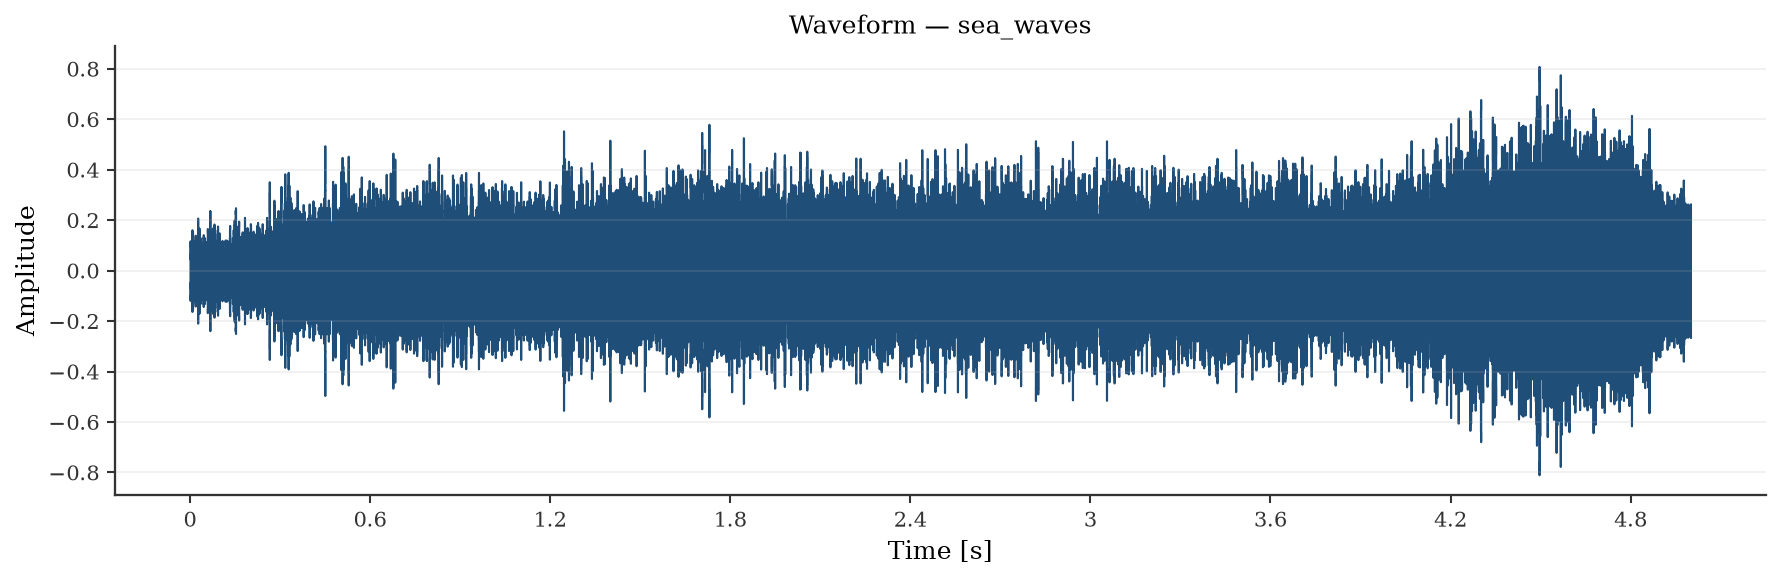

In [7]:
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE, dpi=DPI)

librosa.display.waveshow(
    y,
    sr=sr,
    ax=ax,
    color=ACCENT["blue"],
)

ax.set_title(f"Waveform — {selected_category}")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Amplitude")

clean_axes(ax, grid_axis="y")

plt.tight_layout()
plt.show()

## What kinds of features can we extract?

We will compute a small set of interpretable audio features.

Some features describe the waveform directly:

```text
RMS energy
zero-crossing rate
```

Some features describe the spectrum:

```text
spectral centroid
spectral bandwidth
spectral rolloff
```

Some features describe the log-mel spectral envelope:

```text
MFCCs
```

Since many of these features vary over time, we summarize them using simple statistics:

```text
mean
standard deviation
minimum
maximum
```

## Time-domain feature: RMS energy

RMS energy gives a frame-level measure of signal amplitude.

It is useful to distinguish quiet, sustained, impulsive, or high-energy sounds.

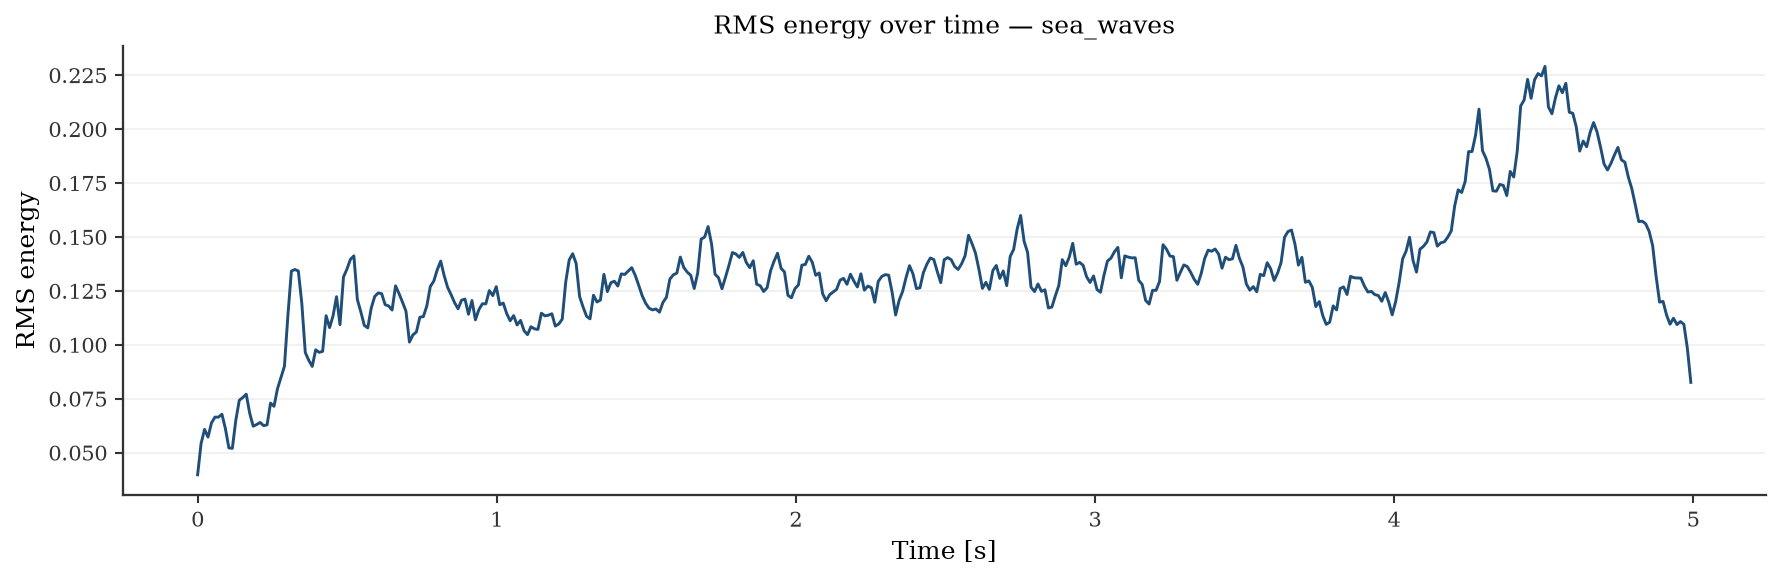

RMS mean: 0.13296671
RMS std: 0.0303542


In [8]:
frame_length = 2048
hop_length = 512

rms = librosa.feature.rms(
    y=y,
    frame_length=frame_length,
    hop_length=hop_length,
)[0]

times = librosa.frames_to_time(
    np.arange(len(rms)),
    sr=sr,
    hop_length=hop_length,
)

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE, dpi=DPI)

ax.plot(
    times,
    rms,
    color=ACCENT["blue"],
    linewidth=1.4,
)

ax.set_title(f"RMS energy over time — {selected_category}")
ax.set_xlabel("Time [s]")
ax.set_ylabel("RMS energy")

clean_axes(ax, grid_axis="y")

plt.tight_layout()
plt.show()

print("RMS mean:", rms.mean())
print("RMS std:", rms.std())

## Time-domain feature: zero-crossing rate

The zero-crossing rate counts how often the waveform changes sign.

It can be useful for distinguishing tonal, noisy, or high-frequency sounds.

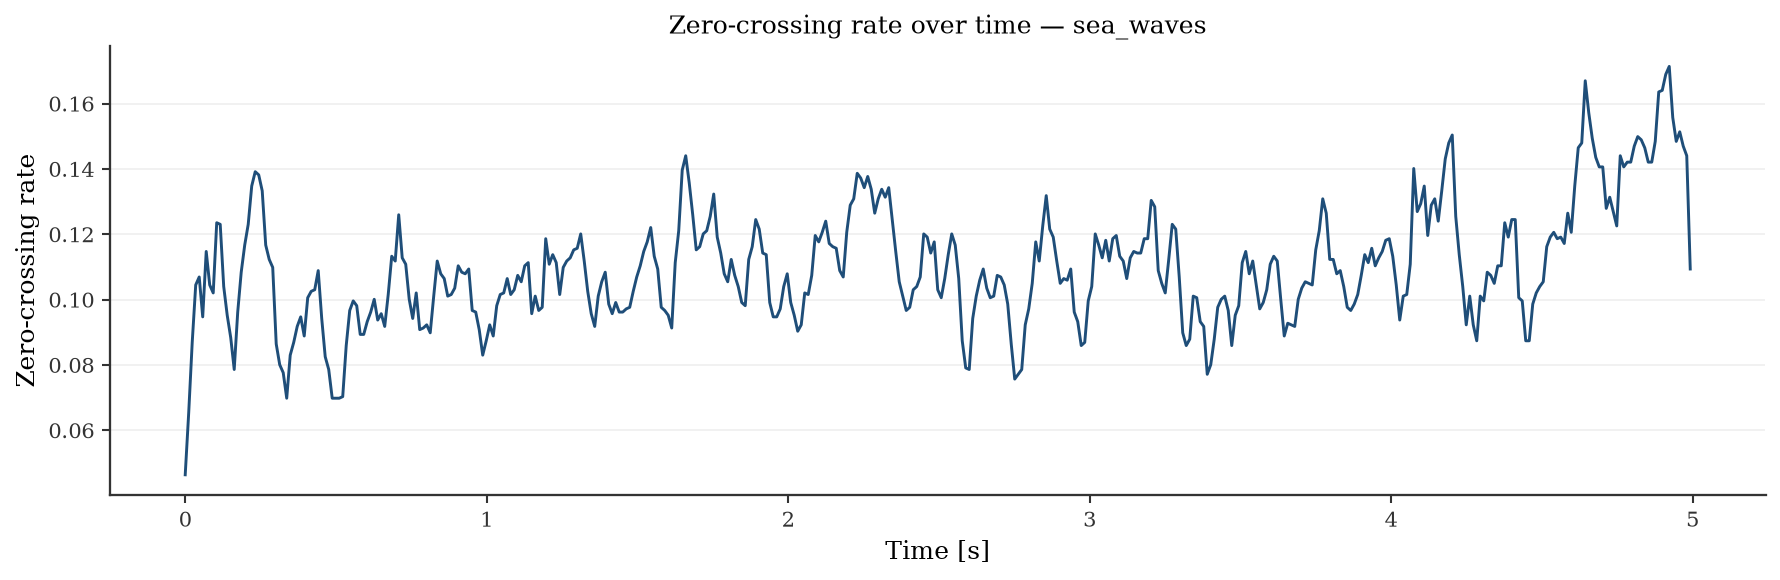

ZCR mean: 0.10975905416183294
ZCR std: 0.018007358404535056


In [9]:
zcr = librosa.feature.zero_crossing_rate(
    y,
    frame_length=frame_length,
    hop_length=hop_length,
)[0]

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE, dpi=DPI)

ax.plot(
    times,
    zcr,
    color=ACCENT["blue"],
    linewidth=1.4,
)

ax.set_title(f"Zero-crossing rate over time — {selected_category}")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Zero-crossing rate")

clean_axes(ax, grid_axis="y")

plt.tight_layout()
plt.show()

print("ZCR mean:", zcr.mean())
print("ZCR std:", zcr.std())

## Spectral features

Spectral features summarize how energy is distributed across frequency.

We will compute:

```text
spectral centroid  → approximate brightness
spectral bandwidth → spread around the centroid
spectral rolloff   → frequency below which most energy is contained
```

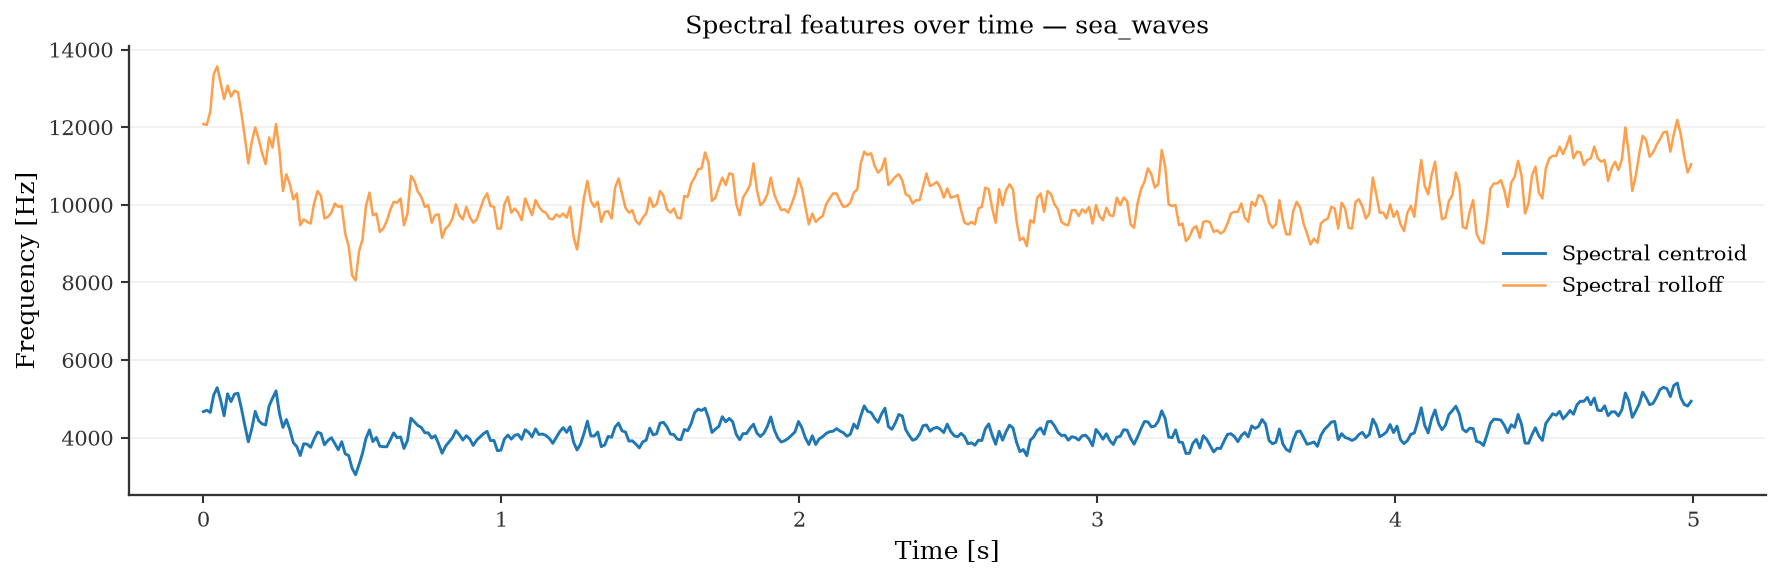

Centroid mean: 4206.905505200439
Bandwidth mean: 4530.454803804736
Rolloff mean: 10234.566573919663


In [10]:
spectral_centroid = librosa.feature.spectral_centroid(
    y=y,
    sr=sr,
    n_fft=frame_length,
    hop_length=hop_length,
)[0]

spectral_bandwidth = librosa.feature.spectral_bandwidth(
    y=y,
    sr=sr,
    n_fft=frame_length,
    hop_length=hop_length,
)[0]

spectral_rolloff = librosa.feature.spectral_rolloff(
    y=y,
    sr=sr,
    n_fft=frame_length,
    hop_length=hop_length,
    roll_percent=0.85,
)[0]

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE, dpi=DPI)

ax.plot(times, spectral_centroid, label="Spectral centroid", linewidth=1.4)
ax.plot(times, spectral_rolloff, label="Spectral rolloff", linewidth=1.2, alpha=0.75)

ax.set_title(f"Spectral features over time — {selected_category}")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")

clean_axes(ax, grid_axis="y")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

print("Centroid mean:", spectral_centroid.mean())
print("Bandwidth mean:", spectral_bandwidth.mean())
print("Rolloff mean:", spectral_rolloff.mean())

## MFCC features

MFCCs summarize the broad shape of the log-mel spectrum.

Here we compute 13 MFCC coefficients over time.

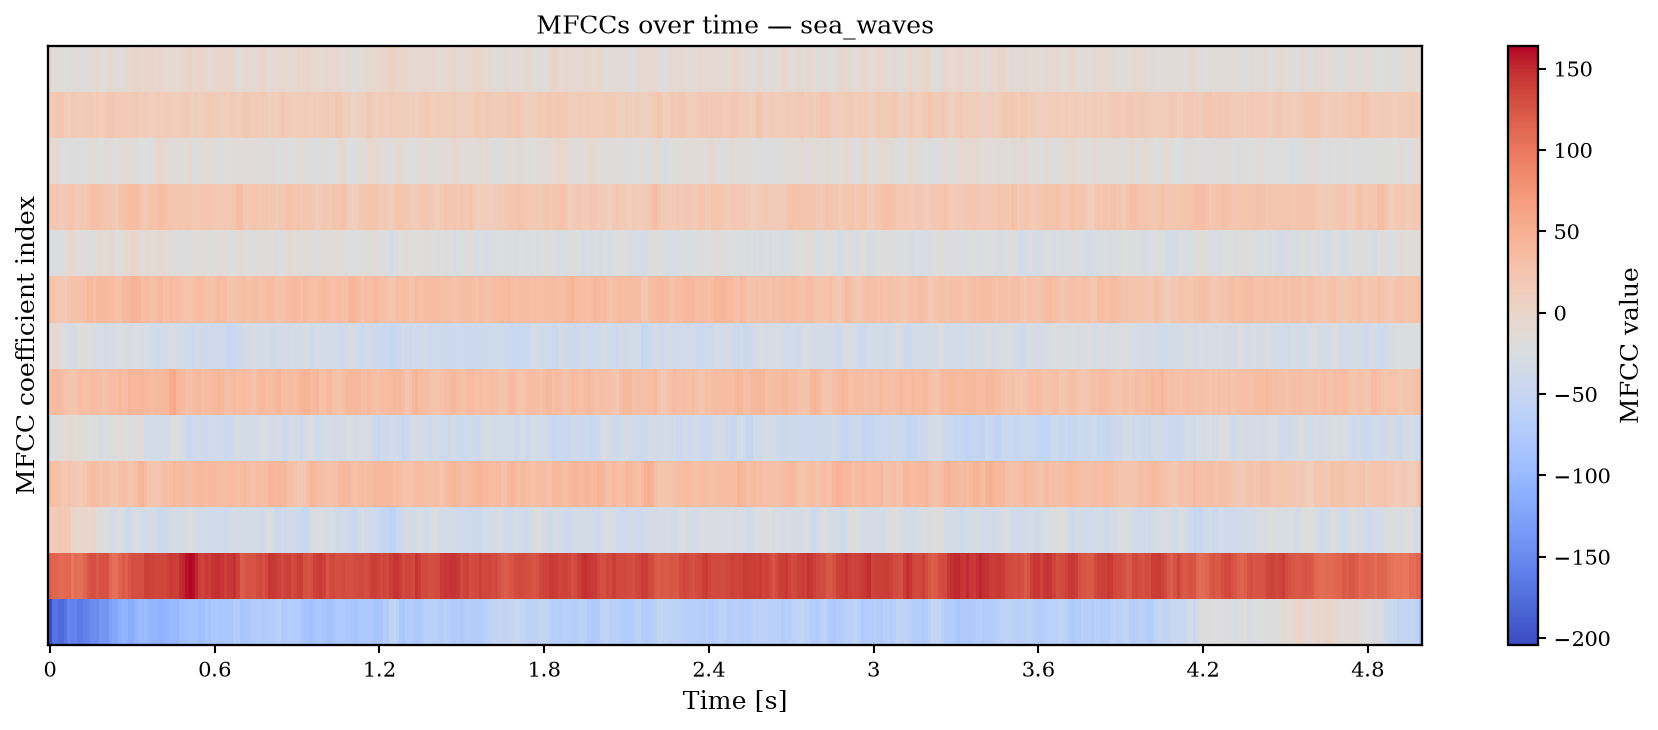

MFCC shape: (13, 431)


In [11]:
n_mfcc = 13

mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=n_mfcc,
    n_fft=frame_length,
    hop_length=hop_length,
)

fig, ax = plt.subplots(figsize=FIGSIZE_TALL, dpi=DPI)

image = librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sr,
    hop_length=hop_length,
    ax=ax,
)

fig.colorbar(image, ax=ax, label="MFCC value")

ax.set_title(f"MFCCs over time — {selected_category}")
ax.set_xlabel("Time [s]")
ax.set_ylabel("MFCC coefficient index")

plt.tight_layout()
plt.show()

print("MFCC shape:", mfcc.shape)

## Helper functions for feature extraction

We now write small functions to:

1. summarize a time-varying feature;
2. extract features from one audio file;
3. repeat the process for all files in the subset.

In [12]:
def summarize_feature(values, prefix):
    """
    Summarize a one-dimensional time-varying feature.
    """
    values = np.asarray(values)

    return {
        f"{prefix}_mean": float(np.mean(values)),
        f"{prefix}_std": float(np.std(values)),
        f"{prefix}_min": float(np.min(values)),
        f"{prefix}_max": float(np.max(values)),
    }


def extract_audio_features(audio_path, sr_target=None):
    """
    Extract a compact set of audio features from one audio file.
    """
    y, sr = librosa.load(audio_path, sr=sr_target, mono=True)

    frame_length = 2048
    hop_length = 512
    n_mfcc = 13

    features = {}

    # Basic metadata
    features["duration_s"] = len(y) / sr
    features["sampling_rate"] = sr

    # Time-domain features
    rms = librosa.feature.rms(
        y=y,
        frame_length=frame_length,
        hop_length=hop_length,
    )[0]

    zcr = librosa.feature.zero_crossing_rate(
        y,
        frame_length=frame_length,
        hop_length=hop_length,
    )[0]

    features.update(summarize_feature(rms, "rms"))
    features.update(summarize_feature(zcr, "zcr"))

    # Spectral features
    centroid = librosa.feature.spectral_centroid(
        y=y,
        sr=sr,
        n_fft=frame_length,
        hop_length=hop_length,
    )[0]

    bandwidth = librosa.feature.spectral_bandwidth(
        y=y,
        sr=sr,
        n_fft=frame_length,
        hop_length=hop_length,
    )[0]

    rolloff = librosa.feature.spectral_rolloff(
        y=y,
        sr=sr,
        n_fft=frame_length,
        hop_length=hop_length,
        roll_percent=0.85,
    )[0]

    features.update(summarize_feature(centroid, "spectral_centroid"))
    features.update(summarize_feature(bandwidth, "spectral_bandwidth"))
    features.update(summarize_feature(rolloff, "spectral_rolloff"))

    # MFCCs
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=frame_length,
        hop_length=hop_length,
    )

    for i in range(n_mfcc):
        features[f"mfcc_{i:02d}_mean"] = float(np.mean(mfcc[i]))
        features[f"mfcc_{i:02d}_std"] = float(np.std(mfcc[i]))

    return features

## Extract features from the ESC-50 subset

This may take a short moment because we process all audio files in the subset.

In [13]:
feature_rows = []

for row in metadata.itertuples(index=False):
    audio_path = SUBSET_AUDIO_DIR / row.filename

    features = extract_audio_features(audio_path)

    features["filename"] = row.filename
    features["category"] = row.category
    features["target"] = row.target

    feature_rows.append(features)

features_df = pd.DataFrame(feature_rows)

# Move metadata columns to the front.
front_columns = ["filename", "category", "target", "duration_s", "sampling_rate"]
other_columns = [col for col in features_df.columns if col not in front_columns]
features_df = features_df[front_columns + other_columns]

print("Feature table shape:", features_df.shape)

features_df.head()

Feature table shape: (80, 51)


,filename,category,target,duration_s,sampling_rate,rms_mean,rms_std,rms_min,rms_max,zcr_mean,...,mfcc_08_mean,mfcc_08_std,mfcc_09_mean,mfcc_09_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std
0,1-100038-A-14.wav,chirping_birds,14,5.0,44100,0.048115,0.038114,0.016259,0.241998,0.157994,...,-11.705071,7.955853,-17.621454,8.934216,-26.893171,10.558152,-13.461914,7.269026,-9.417187,6.993200
1,1-34495-A-14.wav,chirping_birds,14,5.0,44100,0.054410,0.065113,0.014088,0.272005,0.172669,...,-7.826603,8.451578,24.947496,10.026748,-9.441930,7.953942,3.315334,8.974554,-14.367867,6.796442
2,1-34497-A-14.wav,chirping_birds,14,5.0,44100,0.024467,0.007098,0.012339,0.064768,0.214568,...,-20.033266,8.808902,20.341619,7.410479,-19.248188,7.617902,12.599248,7.122535,-23.226843,6.536869
3,1-38559-A-14.wav,chirping_birds,14,5.0,44100,0.009480,0.006181,0.001023,0.023706,0.143265,...,-24.379923,6.393528,5.893976,9.036790,-22.354820,6.079295,-6.182848,9.611876,-15.564694,9.505658
4,1-38560-A-14.wav,chirping_birds,14,5.0,44100,0.005041,0.005941,0.000606,0.025639,0.214983,...,-22.433643,11.821642,-0.792322,7.988717,-19.612755,8.865774,3.564663,6.072551,-17.621767,7.828809


## Save the feature table

The next notebook will use this CSV file for classification.

In [14]:
features_df.to_csv(FEATURES_CSV, index=False)

print("Saved features to:")
print(FEATURES_CSV)

Saved features to:
/Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class/outputs/features/esc50_audio_features.csv


## Inspect the feature table

Each row corresponds to one audio file.

Each column after the metadata columns is a numerical descriptor.

In [15]:
features_df.groupby("category").size()

category
chirping_birds     10
clock_tick         10
dog                10
helicopter         10
keyboard_typing    10
rain               10
sea_waves          10
sneezing           10
dtype: int64

In [16]:
feature_columns = [
    col for col in features_df.columns
    if col not in ["filename", "category", "target"]
]

print("Number of numerical feature columns:", len(feature_columns))
print("First 20 feature columns:")
feature_columns[:20]

Number of numerical feature columns: 48
First 20 feature columns:


['duration_s',
 'sampling_rate',
 'rms_mean',
 'rms_std',
 'rms_min',
 'rms_max',
 'zcr_mean',
 'zcr_std',
 'zcr_min',
 'zcr_max',
 'spectral_centroid_mean',
 'spectral_centroid_std',
 'spectral_centroid_min',
 'spectral_centroid_max',
 'spectral_bandwidth_mean',
 'spectral_bandwidth_std',
 'spectral_bandwidth_min',
 'spectral_bandwidth_max',
 'spectral_rolloff_mean',
 'spectral_rolloff_std']

## Visual comparison of two features

As a first intuition, we can plot two features and color points by class.

This is not yet classification, but it helps us see that audio features can contain class-related structure.

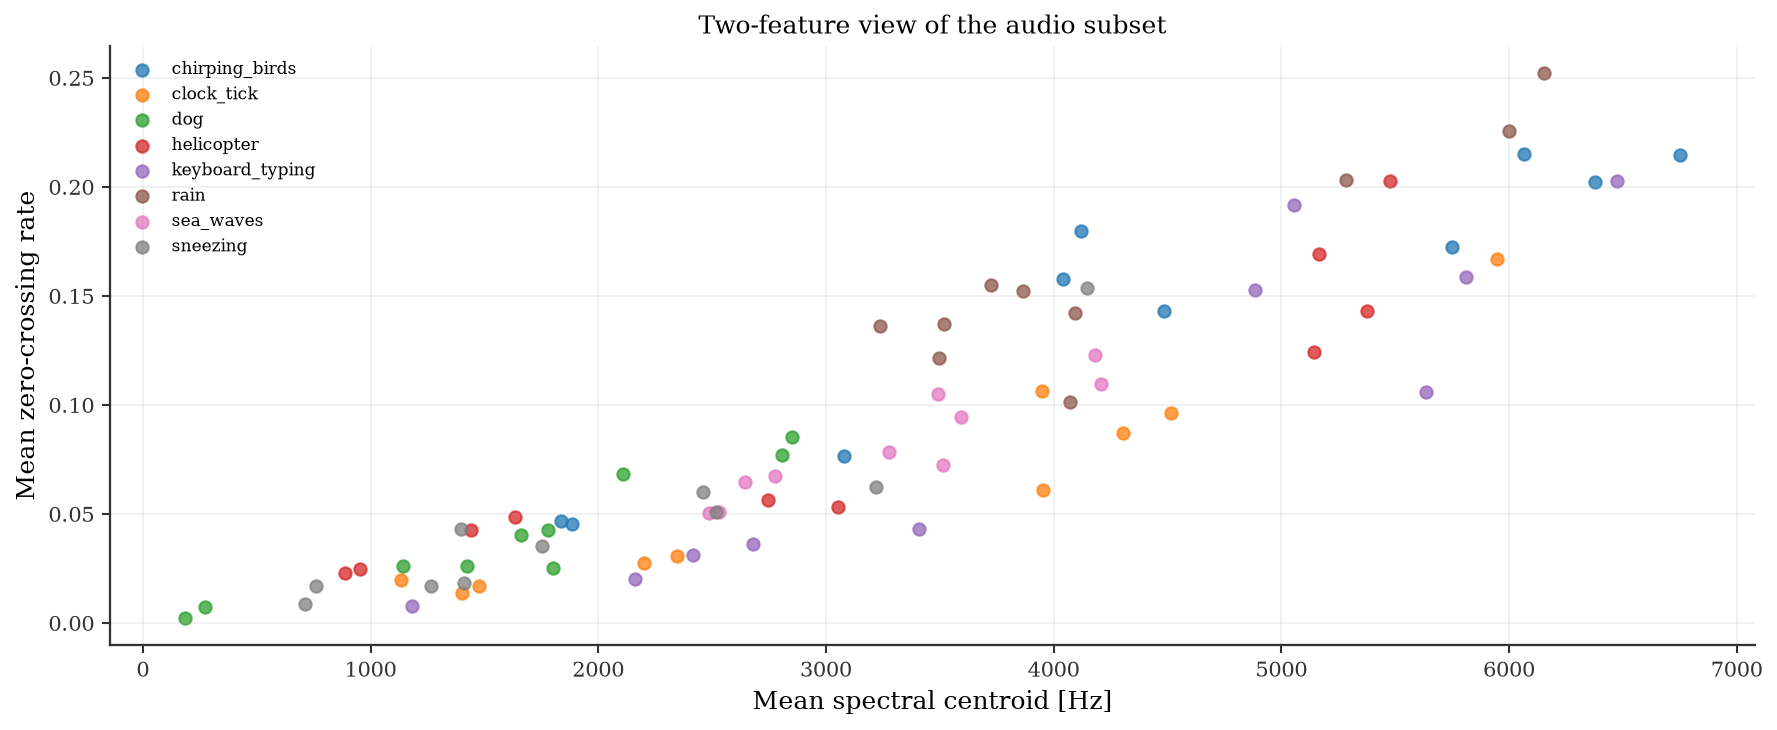

In [17]:
fig, ax = plt.subplots(figsize=FIGSIZE_TALL, dpi=DPI)

for category, group in features_df.groupby("category"):
    ax.scatter(
        group["spectral_centroid_mean"],
        group["zcr_mean"],
        label=category,
        alpha=0.75,
        s=35,
    )

ax.set_title("Two-feature view of the audio subset")
ax.set_xlabel("Mean spectral centroid [Hz]")
ax.set_ylabel("Mean zero-crossing rate")

clean_axes(ax, grid_axis="both")
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

## Summary

In this notebook, we transformed audio files into a feature table.

The pipeline was:

```text
audio file
    ↓
waveform
    ↓
time-domain features
spectral features
MFCC features
    ↓
summary statistics
    ↓
one row per audio file
```

This prepares the dataset for classical machine learning.

In the next notebook, we will train a simple classifier using this feature table.

## Discussion questions

1. Why do we summarize time-varying features using statistics?
2. What might be lost when we reduce an audio file to one feature vector?
3. Which features might help distinguish tonal sounds from noisy sounds?
4. Which features might help distinguish impulsive sounds from sustained sounds?
5. Why are MFCCs useful as compact audio descriptors?